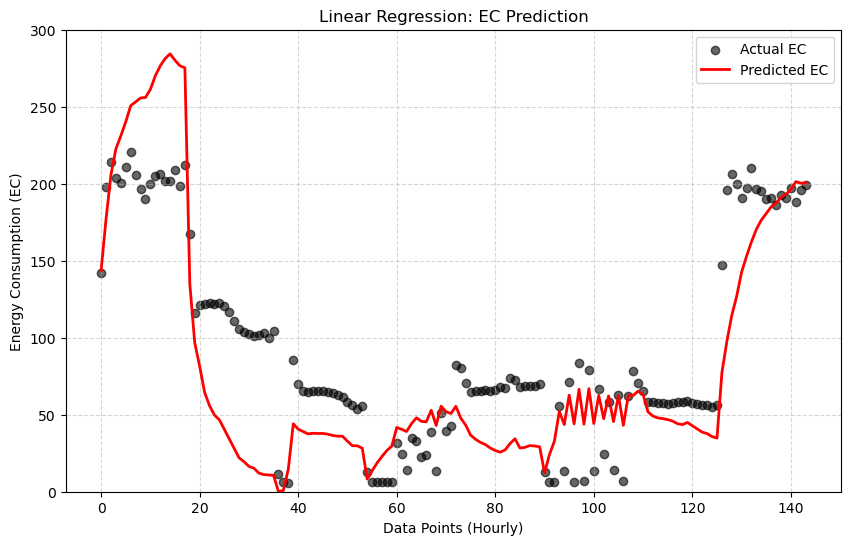

组合模型的总 RMSE: 41.5831


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# 线性模型
# 训练再热除湿
temp_log = "0615data_processed_0_7.csv"
df_temp_log = pd.read_csv(temp_log) # 再热除湿
df_temp_log['Time'] = pd.to_datetime(df_temp_log['Time'])

# 0810一日test
data_XYplot = "0614_0810_data_processed_0_7.csv"
df_XYplot = pd.read_csv(data_XYplot)
df_XYplot['Time'] = pd.to_datetime(df_XYplot['Time'])
start_time = "2025-08-10 00:00:00"
end_time = "2025-08-10 23:50:00"
mask = (df_XYplot['Time'] >= start_time) & (df_XYplot['Time'] <= end_time)
df_test = df_XYplot.loc[mask].reset_index(drop=True)

# 训练冷房模型
start_time_cool = "2025-07-01 00:00:00"
end_time_cool = "2025-07-01 23:50:00"
mask_cool = (df_XYplot['Time'] >= start_time_cool) & (df_XYplot['Time'] <= end_time_cool)
df_cool_full = df_XYplot.loc[mask_cool].reset_index(drop=True)
df_cool = df_cool_full[df_cool_full['mode_real'] == 'cooling'].copy()
df_cool = df_cool.reset_index(drop=True)
#################################数据准备完毕###############################
###########################################################################

X_train_raw_reheat = df_temp_log[['Tout',  'Txiru', 'Q_total', 'Xxiru']] 
y_train_reheat = df_temp_log['Totalenergy']
X_train_raw_cool = df_cool[['Tout',  'Txiru', 'Q_total', 'Xxiru']] 
y_train_cool = df_cool['Totalenergy']

X_test_raw = df_test[['Tout',  'Txiru', 'Q_total', 'Xxiru']] 
y_test = df_test['Totalenergy']

scaler_X_reheat = StandardScaler()
scaler_y_reheat = StandardScaler()
scaler_X_cool = StandardScaler()
scaler_y_cool = StandardScaler()

# --- 2. 训练 Reheat 模型 ---
# 标准化特征和目标
X_train_re_scaled = scaler_X_reheat.fit_transform(X_train_raw_reheat)
y_train_re_scaled = scaler_y_reheat.fit_transform(y_train_reheat.values.reshape(-1, 1))
# 添加常数项并拟合
X_train_re_scaled_const = sm.add_constant(X_train_re_scaled)
model_reheat = sm.OLS(y_train_re_scaled, X_train_re_scaled_const).fit()
# --- 3. 训练 Cool 模型 ---
X_train_co_scaled = scaler_X_cool.fit_transform(X_train_raw_cool)
y_train_co_scaled = scaler_y_cool.fit_transform(y_train_cool.values.reshape(-1, 1))
X_train_co_scaled_const = sm.add_constant(X_train_co_scaled)
model_cool = sm.OLS(y_train_co_scaled, X_train_co_scaled_const).fit()

# Statsmodels 需要手动添加常数项 (截距)
# X_train_const_reheat = sm.add_constant(X_train_raw_reheat)
# model_reheat = sm.OLS(y_train_reheat, X_train_const_reheat).fit()
# print(model_reheat.summary())

# # # 残差图
# residuals = model_reheat.resid
# fitted_values = model_reheat.fittedvalues
# plt.figure(figsize=(10, 6))
# sns.scatterplot(x=fitted_values, y=residuals)
# plt.axhline(y=0, color='red', linestyle='--')
# plt.xlabel('Fitted Values (Predicted EC)')
# plt.ylabel('Residuals')
# plt.title('Residuals vs Fitted Values')
# plt.show()

# X_train_const_cool = sm.add_constant(X_train_raw_cool)
# model_cool = sm.OLS(y_train_cool, X_train_const_cool).fit()
# print(model_cool.summary())

P_totals_scaled = []   # 存储标准化后的预测值
P_totals_original_linear = [] # 存储还原后的物理值

# 预先处理好两种模式下的测试集特征（基于各自训练集的均值和方差）
X_test_for_reheat = scaler_X_reheat.transform(X_test_raw)
X_test_for_cool = scaler_X_cool.transform(X_test_raw)

for i in range(len(X_test_raw)):
    # 逻辑判断
    if i < 18 or i >= 126:
        # 使用 Reheat 模式
        current_x = np.insert(X_test_for_reheat[i], 0, 1) # 添加 const
        pred_s = model_reheat.predict(current_x)[0]
        # 还原
        pred_o = scaler_y_reheat.inverse_transform([[pred_s]])[0][0]
    else:
        # 使用 Cool 模式
        current_x = np.insert(X_test_for_cool[i], 0, 1)   # 添加 const
        pred_s = model_cool.predict(current_x)[0]
        # 还原
        pred_o = scaler_y_cool.inverse_transform([[pred_s]])[0][0]
    
    pred_o = max(0, pred_o)

    P_totals_scaled.append(pred_s)
    P_totals_original_linear.append(pred_o)

def plot_CI(P_totals, y_test):
    # 画图
    plt.figure(figsize=(10, 6))
    # 设置索引或时间作为 X 轴进行展示
    x_axis = range(len(P_totals))
    # 绘制实际观测值
    plt.scatter(x_axis, y_test, color='black', label='Actual EC', alpha=0.6)
    # 绘制模型预测线
    plt.plot(x_axis, P_totals, color='red', label='Predicted EC', linewidth=2)
    plt.title('Linear Regression: EC Prediction')
    plt.xlabel('Data Points (Hourly)')
    plt.ylabel('Energy Consumption (EC)')
    plt.ylim(0,300)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# def plot_parity(pred_summary, y_test):
#     plt.figure(figsize=(8, 8))
#     # 1. 绘制散点图
#     plt.scatter(y_test, pred_summary['mean'].clip(lower=0), color='royalblue', alpha=0.6, label='Predicted vs Actual')
#     # 2. 绘制 y = x 虚线，范围从 0 到 200
#     reference_line = [0, 300]
#     plt.plot(reference_line, reference_line, color='red', linestyle='--', linewidth=2, label='Identity Line (y=x)')
#     # 3. 强制设置坐标轴范围为 0-200
#     plt.xlim(0, 300)
#     plt.ylim(0, 300)
#     # 保持 1:1 的视觉比例，确保 y=x 是完美的 45 度角
#     plt.gca().set_aspect('equal', adjustable='box')
#     # 图表修饰
#     plt.title('EC Prediction Accuracy (Range: 0-200)')
#     plt.xlabel('Actual Energy Consumption')
#     plt.ylabel('Predicted Energy Consumption')
#     plt.legend()
#     plt.grid(True, linestyle=':', alpha=0.6)
#     plt.show()

plot_CI(P_totals_original_linear,y_test)
# plot_parity(pred_summary, y_test)

# 确保 y_test 和 P_totals 长度一致
y_true = df_test['Totalenergy'].values
rmse = np.sqrt(mean_squared_error(y_true, P_totals_original_linear))
print(f"组合模型的总 RMSE: {rmse:.4f}")

弄一个普通的神经网络

正在训练 Reheat 模型...
正在训练 Cool 模型...


d:\Installation\Anaconda3-2021.11-Windows-x86_64\envs\apart2025copy\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\Installation\Anaconda3-2021.11-Windows-x86_64\envs\apart2025copy\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\Installation\Anaconda3-2021.11-Windows-x86_64\envs\apart2025copy\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\Installation\Anaconda3-2021.11-Windows-x86_64\envs\apart2025copy\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\Installation\Anaconda3-2021.11-Windows-x86_64\envs\apart2025copy\lib\site-packages\sklearn\base.py:450: U

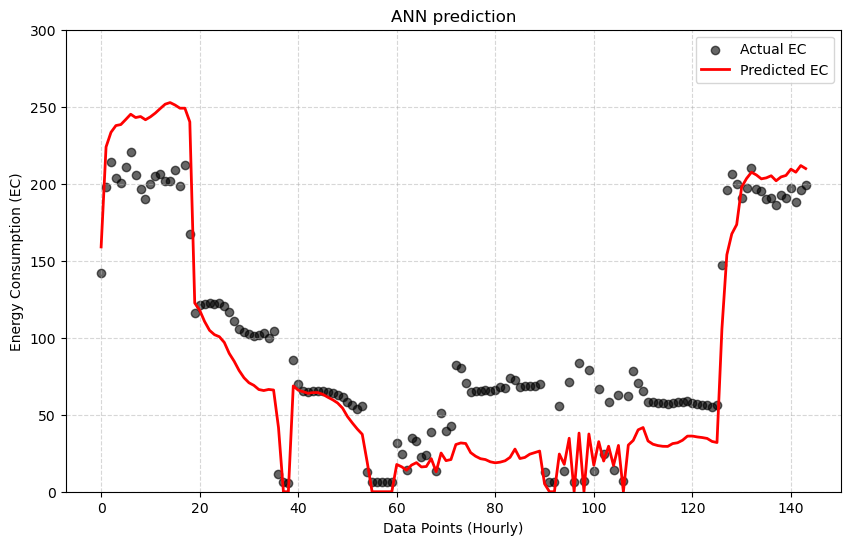

RMSE:  28.773689993770564


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler

X_train_raw_reheat = df_temp_log[['Tout',  'Txiru', 'Q_total', 'Xxiru']] 
y_train_reheat = df_temp_log['Totalenergy']
X_train_raw_cool = df_cool[['Tout',  'Txiru', 'Q_total', 'Xxiru']] 
y_train_cool = df_cool['Totalenergy']

X_test_raw = df_test[['Tout',  'Txiru', 'Q_total', 'Xxiru']] 
y_test = df_test['Totalenergy']

# --- 标准化训练集 ---
# Reheat 部分
scaler_X_reheat = StandardScaler()
scaler_y_reheat = StandardScaler()
X_train_re_scaled = scaler_X_reheat.fit_transform(X_train_raw_reheat)
y_train_re_scaled = scaler_y_reheat.fit_transform(y_train_reheat.values.reshape(-1, 1))

# Cool 部分
scaler_X_cool = StandardScaler()
scaler_y_cool = StandardScaler()
X_train_co_scaled = scaler_X_cool.fit_transform(X_train_raw_cool)
y_train_co_scaled = scaler_y_cool.fit_transform(y_train_cool.values.reshape(-1, 1))

# 转换为 PyTorch Tensors
X_re_tensor = torch.tensor(X_train_re_scaled, dtype=torch.float32)
y_re_tensor = torch.tensor(y_train_re_scaled, dtype=torch.float32)
X_co_tensor = torch.tensor(X_train_co_scaled, dtype=torch.float32)
y_co_tensor = torch.tensor(y_train_co_scaled, dtype=torch.float32)

class EnergyANN(nn.Module):
    def __init__(self, input_size=4):
        super(EnergyANN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
        
    def forward(self, x):
        return self.net(x)

# 实例化两个独立的模型
model_reheat = EnergyANN()
model_cool = EnergyANN()

def train_model(model, X, y, epochs=100):
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.MSELoss()
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
    return model

print("正在训练 Reheat 模型...")
model_reheat = train_model(model_reheat, X_re_tensor, y_re_tensor)
print("正在训练 Cool 模型...")
model_cool = train_model(model_cool, X_co_tensor, y_co_tensor)

X_test_values = X_test_raw.values
P_totals_original_ANN = []

model_reheat.eval()
model_cool.eval()

with torch.no_grad():
    for i in range(len(X_test_values)):
        # 获取单行数据并转为 2D 数组 (1, 4)
        current_raw = X_test_values[i].reshape(1, -1)
        
        if i <= 18 or i >= 126:
            if df_test["Totalenergy"][i] < 10:
                pred_final = 0
            else:
                # 1. 使用 Reheat 标准化器转换输入
                input_scaled = scaler_X_reheat.transform(current_raw)
                input_tensor = torch.tensor(input_scaled, dtype=torch.float32)
                # 2. 预测并获取标准化后的值
                pred_scaled = model_reheat(input_tensor).item()
                # 3. 还原回物理单位
                pred_final = scaler_y_reheat.inverse_transform([[pred_scaled]])[0][0]
        else:
            if df_test["Totalenergy"][i] < 10:
                pred_final = 0
            else:
                # 1. 使用 Cool 标准化器转换输入
                input_scaled = scaler_X_cool.transform(current_raw)
                input_tensor = torch.tensor(input_scaled, dtype=torch.float32)
                # 2. 预测
                pred_scaled = model_cool(input_tensor).item()
                # 3. 还原
                pred_final = scaler_y_cool.inverse_transform([[pred_scaled]])[0][0]

        pred_final = max(0, pred_final)
        P_totals_original_ANN.append(pred_final)

plt.figure(figsize=(10, 6))
# 设置索引或时间作为 X 轴进行展示
x_axis = range(len(P_totals_original_ANN))
# 绘制实际观测值
plt.scatter(x_axis, y_test, color='black', label='Actual EC', alpha=0.6)
# 绘制模型预测线
plt.plot(x_axis, P_totals_original_ANN, color='red', label='Predicted EC', linewidth=2)
plt.title('ANN prediction')
plt.xlabel('Data Points (Hourly)')
plt.ylabel('Energy Consumption (EC)')
plt.ylim(0,300)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

RMSE = np.sqrt(np.mean((np.array(P_totals_original_ANN).flatten() - y_test.values.flatten())**2))
print("RMSE: ", RMSE)

用LSTM

正在训练 Reheat LSTM...
正在训练 Cool LSTM...

混合 LSTM 模型测试集 RMSE: 32.1022


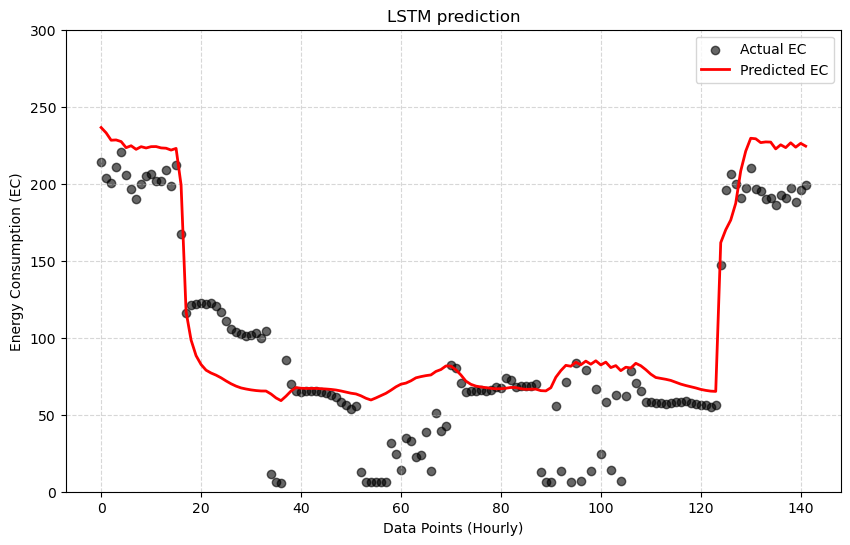

142


In [4]:
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler

def create_sequences(data, target, window_size=3):
    X, y = [], []
    for i in range(len(data) - window_size + 1):
        # 提取从 i 到 i + window_size 的特征
        X.append(data[i : i + window_size])
        # 目标值通常取窗口最后一行对应的结果
        y.append(target[i + window_size - 1])
    return np.array(X), np.array(y)

X_train_raw_reheat = df_temp_log[['Tout',  'Txiru', 'Q_total', 'Xxiru']] 
y_train_reheat = df_temp_log['Totalenergy']
X_train_raw_cool = df_cool[['Tout',  'Txiru', 'Q_total', 'Xxiru']] 
y_train_cool = df_cool['Totalenergy']

X_test_raw = df_test[['Tout',  'Txiru', 'Q_total', 'Xxiru']] 
y_test = df_test['Totalenergy']

# --- 1.1 分别标准化 ---
scaler_X_reheat = StandardScaler()
scaler_y_reheat = StandardScaler()
X_re_scaled = scaler_X_reheat.fit_transform(X_train_raw_reheat)
y_re_scaled = scaler_y_reheat.fit_transform(y_train_reheat.values.reshape(-1, 1))

scaler_X_cool = StandardScaler()
scaler_y_cool = StandardScaler()
X_co_scaled = scaler_X_cool.fit_transform(X_train_raw_cool)
y_co_scaled = scaler_y_cool.fit_transform(y_train_cool.values.reshape(-1, 1))

# --- 1.2 构造 3D 序列 (window_size=3) ---
window_size = 3
X_re_seq, y_re_seq = create_sequences(X_re_scaled, y_re_scaled, window_size)
X_co_seq, y_co_seq = create_sequences(X_co_scaled, y_co_scaled, window_size)

# 转换为 Tensor
X_re_tensor = torch.tensor(X_re_seq, dtype=torch.float32)
y_re_tensor = torch.tensor(y_re_seq, dtype=torch.float32)
X_co_tensor = torch.tensor(X_co_seq, dtype=torch.float32)
y_co_tensor = torch.tensor(y_co_seq, dtype=torch.float32)

class EnergyLSTM(nn.Module):
    def __init__(self, input_size=4, hidden_size=64):
        super(EnergyLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=2, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        # x 形状: [batch, 3, 4]
        out, _ = self.lstm(x)
        # 取最后一个时间步的输出: out[:, -1, :]
        out = self.fc(out[:, -1, :])
        return out

model_reheat = EnergyLSTM()
model_cool = EnergyLSTM()

def train_lstm(model, X, y, epochs=200):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
    criterion = nn.MSELoss()
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        output = model(X)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()
    return model

print("正在训练 Reheat LSTM...")
model_reheat = train_lstm(model_reheat, X_re_tensor, y_re_tensor)
print("正在训练 Cool LSTM...")
model_cool = train_lstm(model_cool, X_co_tensor, y_co_tensor)

# 1. 准备测试集特征并进行两种方式的标准化
X_test_re_scaled = scaler_X_reheat.transform(X_test_raw)
X_test_co_scaled = scaler_X_cool.transform(X_test_raw)

P_totals_original = []
model_reheat.eval()
model_cool.eval()

with torch.no_grad():
    # 从 window_size - 1 开始遍历，确保前面有足够的行数构造窗口
    for i in range(window_size - 1, len(X_test_raw)):
        
        if i <= 18 or i >= 126:
            # 构造 Reheat 模式的 3D 输入 [1, 3, 4]
            current_seq = X_test_re_scaled[i-window_size+1 : i+1]
            input_tensor = torch.tensor(current_seq, dtype=torch.float32).unsqueeze(0)
            pred_s = model_reheat(input_tensor).item()
            pred_f = scaler_y_reheat.inverse_transform([[pred_s]])[0][0]
        else:
            current_seq = X_test_co_scaled[i-window_size+1 : i+1]
            input_tensor = torch.tensor(current_seq, dtype=torch.float32).unsqueeze(0)
            pred_s = model_cool(input_tensor).item()
            pred_f = scaler_y_cool.inverse_transform([[pred_s]])[0][0]

        pred_f = max(0, pred_f)
        P_totals_original.append(pred_f)

# --- 误差计算 (注意 y_test 也要切掉前两行以对齐) ---
y_test_aligned = y_test.values[window_size-1:]
rmse = np.sqrt(np.mean((np.array(P_totals_original) - y_test_aligned)**2))

print(f"\n混合 LSTM 模型测试集 RMSE: {rmse:.4f}")

plt.figure(figsize=(10, 6))
# 设置索引或时间作为 X 轴进行展示
x_axis = range(len(P_totals_original))
# 绘制实际观测值
plt.scatter(x_axis, y_test_aligned, color='black', label='Actual EC', alpha=0.6)
# 绘制模型预测线
plt.plot(x_axis, P_totals_original, color='red', label='Predicted EC', linewidth=2)
plt.title('LSTM prediction')
plt.xlabel('Data Points (Hourly)')
plt.ylabel('Energy Consumption (EC)')
plt.ylim(0,300)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(len(P_totals_original))
P_totals_original = np.array(P_totals_original, dtype=float)
P_totals_original = np.concatenate(([np.nan, np.nan], P_totals_original))

三个模型的比较

              Time     Tout   RHout     Tevp1      Tevp2  Tevp3  Totalenergy  \
0  2025/06/15 0:00  22.4832  97.109  6.698333  25.633333  26.57        178.0   
1  2025/06/15 0:10  22.5560  97.240  6.715000  25.668333  26.60        179.9   

      Tcndin    Tcndout    Txiru  ...      M_in  Xchuichu     Xxiru  \
0  26.101667  28.455833  22.4761  ...  0.130239  0.008416  0.010241   
1  26.134167  28.433333  22.5294  ...  0.130215  0.008489  0.010299   

     Q_latent  Q_sensible    Q_total  mode  temp_setting  volume_setting  \
0  594.342877  275.890203  870.23308   dry           NaN            auto   
1  589.380665  258.826874  848.20754   dry           NaN            auto   

  mode_real  
0    reheat  
1    reheat  

[2 rows x 23 columns]


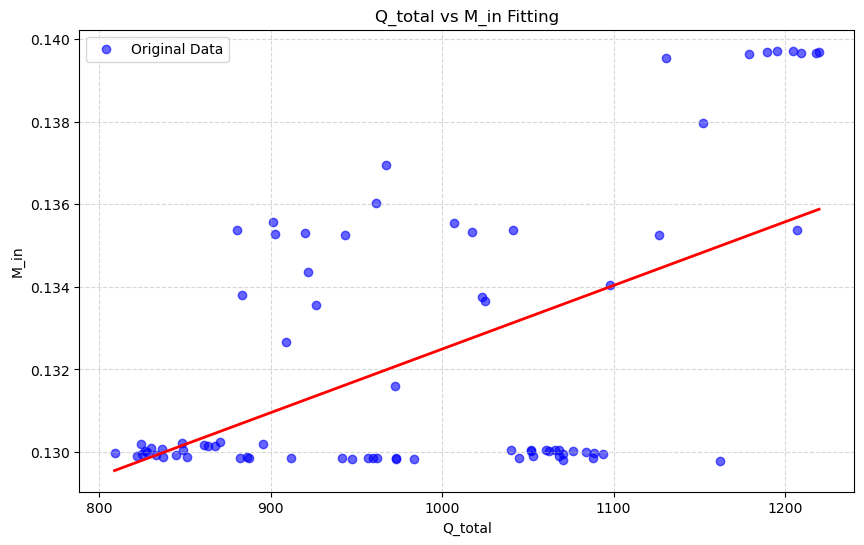

[ 0.00060272 -0.43612269]
P_c:, 73.4550029838023


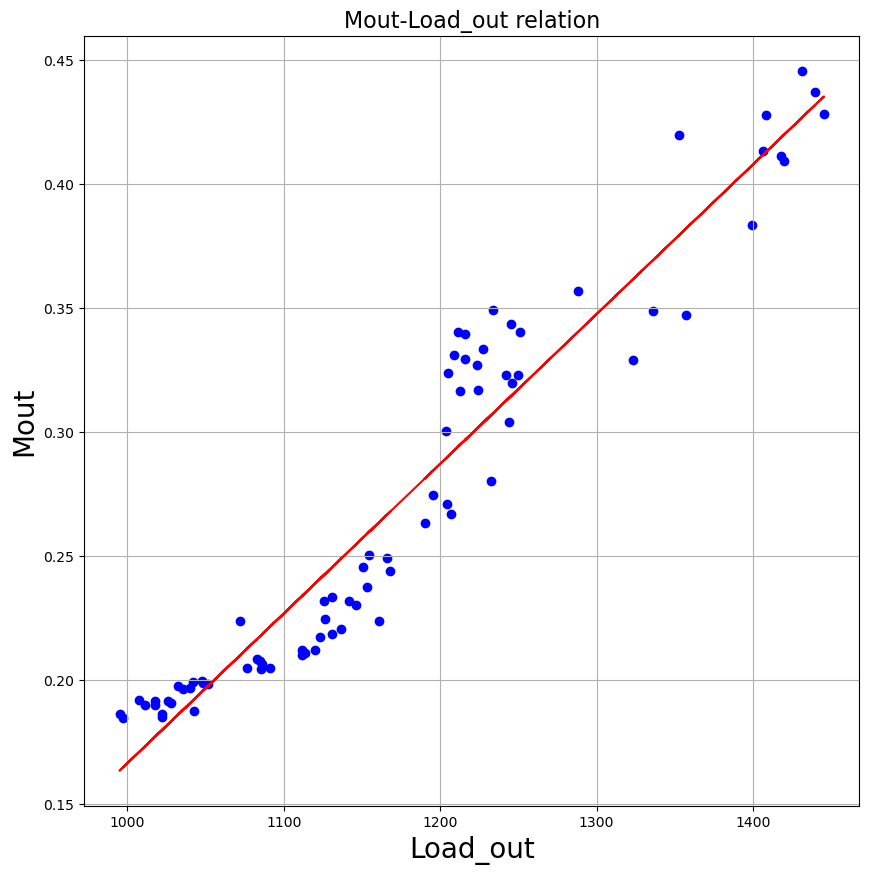

[-1.44113952e-07 -6.10014216e-05  1.32367866e+00]
              Time       Tout      RHout      Tevp1      Tevp2      Tevp3  \
0  2025/07/01 6:00  27.604800  75.928000  22.431667  22.758333  21.011667   
1  2025/07/01 6:10  27.970133  74.448167  21.930000  22.611667  21.950000   

   Totalenergy     Tcndin    Tcndout    Txiru  ...      M_in  Xchuichu  \
0         91.5  21.885000  30.309167  25.6679  ...  0.142525  0.014483   
1         79.5  22.280833  30.105000  25.5264  ...  0.142593  0.015321   

      Xxiru    Q_latent  Q_sensible     Q_total     mode  temp_setting  \
0  0.014924  157.177946  381.888257  539.066203  cooling            27   
1  0.015577   91.491780  440.149397  531.641177  cooling            27   

   volume_setting mode_real  
0     medium-high   cooling  
1     medium-high   cooling  

[2 rows x 23 columns]
P_c: 80.1945290780290
--------------------------------------------------------------
real energy 142.2 0
Q_total: 589.5705063 gamma_cooled, reheat_a, reheat_b,

d:\Installation\Anaconda3-2021.11-Windows-x86_64\envs\apart2025copy\lib\site-packages\scipy\optimize\_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


Calculated energy: 143.713364417341
--------------------------------------------------------------
real energy 199.8 129
Calculated energy: 145.853954970634
--------------------------------------------------------------
real energy 191.0 130
Calculated energy: 159.629335096092
--------------------------------------------------------------
real energy 197.0 131
Calculated energy: 169.660671219137
--------------------------------------------------------------
real energy 210.4 132
Calculated energy: 178.203515931149
--------------------------------------------------------------
real energy 196.5 133
Calculated energy: 180.580974124745
--------------------------------------------------------------
real energy 195.1 134
P_aircon: 184.990356414073 Q_total: 997.6114258 gamma_cooled, reheat_a, reheat_b, BP: 0.4799914500614519 0.0 0.5 0.1 当前solve_main_eqs未收敛
Calculated energy: 181.900830655544
--------------------------------------------------------------
real energy 190.3 135
Calculated energ

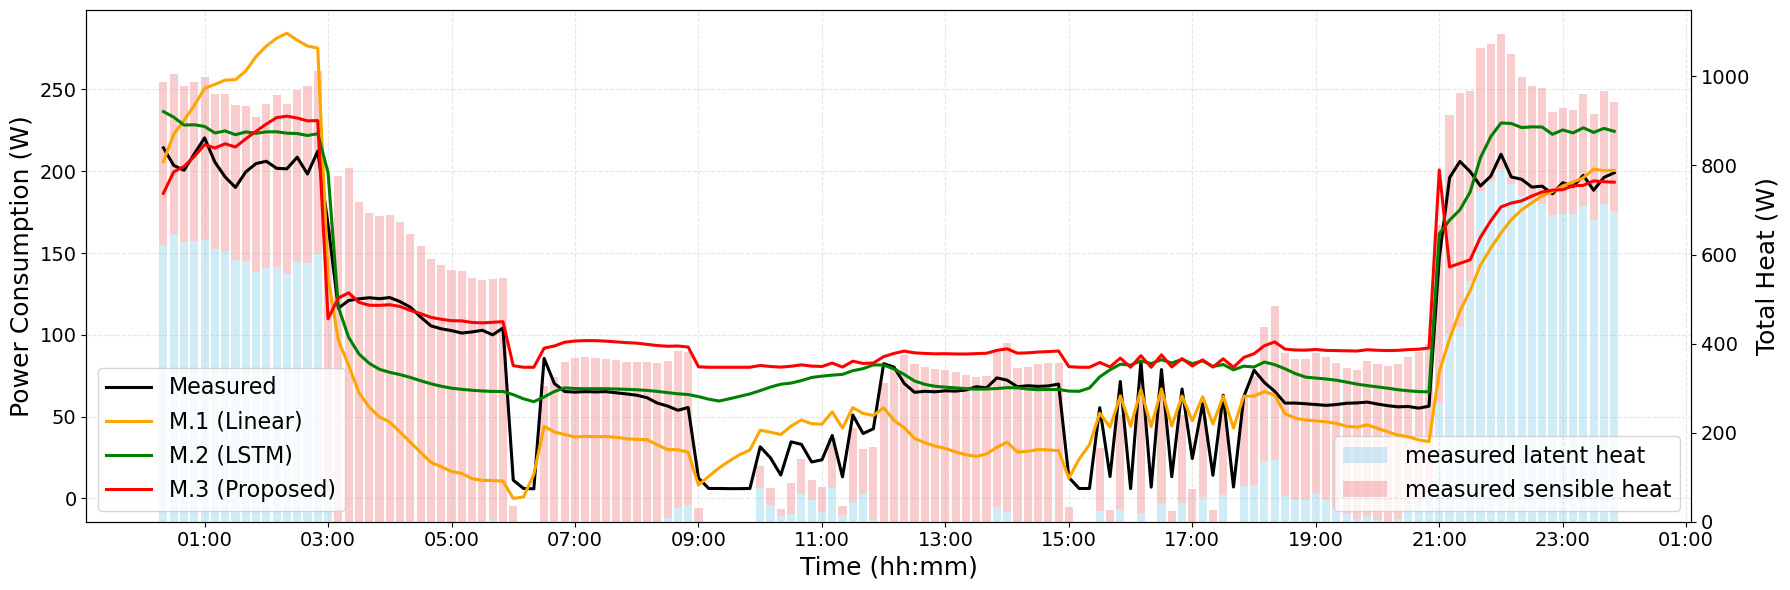

---------------------rmse---------------------
ourmodel: 37.44597506431897 lstm: 32.1021698415517 linear: 41.839414392054415
---------------------mae---------------------
ourmodel: 30.223026751764504 lstm: 25.401582571522283 linear: 32.81668111392452


In [ ]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import CoolProp.CoolProp as HAP
import sympy as sp
from scipy.optimize import minimize_scalar
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from scipy.optimize import differential_evolution
from scipy import interpolate
from sklearn.metrics import mean_squared_error

import reheat_dehumidification as rm
# import good_cooling_model_pack as cm
import cooling_dehumidification as cm

experiment_data = "0615data_processed_0_7.csv"
ac_reheat = rm.reheat_aircon(0.1,0.1,500,2200,3300,115,425,960,906,2160,experiment_data) #室内機bypass　factor （电中研） , 室外機bypass factor （电中研）, 最小能力、定格能力、最大能力,最小EC,定格EC,最大EC,室内機風量（仕様書）、室外機風量（仕様書）,一日の実験データ
experiment_data_cooling = "0701data_processed_0_7.csv"
ac_cool = cm.heating_aircon(0.1,0.1,500,2200,3300,115,425,960,906,2160, experiment_data_cooling) # self, BP_in,BP_out,L_low,L_medium,L_high,P_low,P_medium,P_high,Q_in,Q_out,Q_in_apply

test_data_XYplot = "0614_0810_data_processed_0_7.csv"
df_test1 = pd.read_csv(test_data_XYplot)
df_test1['Time'] = pd.to_datetime(df_test1['Time'])
start_time = "2025-08-10 00:00:00"
end_time = "2025-08-10 23:50:00"
mask = (df_test1['Time'] >= start_time) & (df_test1['Time'] <= end_time)
df_test = df_test1.loc[mask].reset_index(drop=True)

P_totals = []
Q_latents = []
T_evps = []
T_cndins = []
SHFs = []

########################################
# 0810一天
########################################
for e in range(len(df_test)):
    print("--------------------------------------------------------------")
    print("real energy",df_test["Totalenergy"][e],e)
    # if df_test["Totalenergy"][e] < 10:
    #     P, T_evp_apply, T_cnd_apply, Q_latent_cal, SHF = 0,0,0,0,0
    if e <= 17 or e >= 126:
        P, T_evp_apply, T_cnd_apply, Q_latent_cal, SHF = ac_reheat.output(300, df_test["Xxiru"][e], df_test["Txiru"][e], df_test["Tout"][e], (df_test["Q_sensible"][e] + df_test["Q_latent"][e]), 10)
    elif (e >= 36 and e <= 71) or (e >= 90 and e <= 125):
        P, Lsensible_apply, Q_latent_cal, T_evp_apply, T_cnd_apply = ac_cool.ac_output(df_test["Q_total"][e],df_test["Txiru"][e],df_test["Xxiru"][e],df_test["Tout"][e], 576) # 冷房小风量：6:00-12:00, 15:00-21:00
    else:
        P, Lsensible_apply, Q_latent_cal, T_evp_apply, T_cnd_apply = ac_cool.ac_output(df_test["Q_total"][e],df_test["Txiru"][e],df_test["Xxiru"][e],df_test["Tout"][e], 906) # 冷房大风量：3:00-6:00, 12:00-15:00
        
    print("Calculated energy:", P)
    P_totals.append(P)
    Q_latents.append(Q_latent_cal)


# 能耗结果
df_test['Time'] = pd.to_datetime(df_test['Time'])
import matplotlib.dates as mdates
totalenergy_plot = df_test['Totalenergy'].copy()
totalenergy_plot.iloc[:2] = np.nan

P_totals_plot = np.array(P_totals, dtype=float).copy()
P_totals_plot[:2] = np.nan
print(len(P_totals_plot))

print(len(P_totals_original))

P_totals_original_linear = np.array(P_totals_original_linear, dtype=float)
P_totals_original_linear[:2] = np.nan

Q_sensible_array = np.array(df_test['Q_sensible'].values, dtype = float)
Q_sensible_array[:2] = np.nan
Q_latent_array = np.array(df_test['Q_latent'].values, dtype = float)
Q_latent_array[:2] = np.nan

# plt.figure(figsize=(12, 6))
# plt.plot(df_test['Time'], totalenergy_plot, label='Measured energy', color='black')
# plt.plot(df_test['Time'], P_totals_plot, label='Calculated energy', color='red')
# plt.plot(df_test['Time'], P_totals_original, label='lstm', color='green')
# plt.plot(df_test['Time'], P_totals_original_linear, label='Linear model', color='orange')
# plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=2))
# plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
# plt.xlabel('Time (hh:mm)', fontsize=14)
# plt.ylabel('Energy (W)', fontsize=14)
# plt.title('Measured vs Calculated Energy Over Time', fontsize=16)
# plt.legend(fontsize=12)
# # plt.ylim(0,500)
# plt.grid(True)
# plt.tight_layout()
# plt.show()

fig, ax1 = plt.subplots(figsize=(18, 6))
ax2 = ax1.twinx()
width = 0.0055
ax2.bar(df_test['Time'], Q_latent_array, width=width, 
        label='measured latent heat', color='skyblue', alpha=0.39)
ax2.bar(df_test['Time'], Q_sensible_array, width=width, 
        bottom=Q_latent_array, label='measured sensible heat', color='lightcoral', alpha=0.39)

ax2.set_ylabel('Total Heat (W)', fontsize=18)
ax2.legend(loc='lower right', fontsize=16)
ax2.tick_params(axis='y', which='major', labelsize=14)

line_zorder = 10 
ax1.plot(df_test['Time'], totalenergy_plot, label='Measured', 
         color='black', linewidth=2.2, zorder=line_zorder) # 稍微加粗Measured
ax1.plot(df_test['Time'], P_totals_original_linear, label='M.1 (Linear)', 
         color='orange', linewidth=2.2, zorder=line_zorder)
ax1.plot(df_test['Time'], P_totals_original, label='M.2 (LSTM)', 
         color='green', linewidth=2.2, zorder=line_zorder)
ax1.plot(df_test['Time'], P_totals_plot, label='M.3 (Proposed)', 
         color='red', linewidth=2.2, zorder=line_zorder)
ax1.set_xlabel('Time (hh:mm)', fontsize=18)
ax1.set_ylabel('Power Consumption (W)', fontsize=18)
ax1.legend(loc='lower left', fontsize=16)
# --- 3. 核心步骤：调整图层顺序和透明度 ---
# 将 ax1 (线条) 的层级放到 ax2 (柱子) 之上
ax1.set_zorder(ax2.get_zorder() + 1)
# **非常重要**：必须将 ax1 的背景设置为透明，否则 ax2 会被完全遮挡
ax1.patch.set_visible(False) 
# --- 4. 格式化时间轴 ---
# 注意：所有的格式化必须在 ax1 上进行，因为它现在是顶层
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
# plt.title('Measured vs Calculated Energy with Q Components', fontsize=16)
ax1.grid(True, linestyle='--', alpha=0.3, zorder=0) 
ax1.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

# 计算RMSE
rmse_ourmodel = np.sqrt(mean_squared_error(totalenergy_plot[2:], P_totals_plot[2:]))
rmse_lstm = np.sqrt(mean_squared_error(totalenergy_plot[2:], P_totals_original[2:]))
rmse_linear = np.sqrt(mean_squared_error(totalenergy_plot[2:], P_totals_original_linear[2:]))
# 计算MSE
mse_ourmodel = mean_squared_error(totalenergy_plot[2:], P_totals_plot[2:])
mse_lstm = mean_squared_error(totalenergy_plot[2:], P_totals_original[2:])
mse_linear = mean_squared_error(totalenergy_plot[2:], P_totals_original_linear[2:])
# 计算MAE
mae_ourmodel = mean_absolute_error(totalenergy_plot[2:], P_totals_plot[2:])
mae_lstm = mean_absolute_error(totalenergy_plot[2:], P_totals_original[2:])
mae_linear = mean_absolute_error(totalenergy_plot[2:], P_totals_original_linear[2:])

print("---------------------rmse---------------------")
print("ourmodel:", rmse_ourmodel, "lstm:", rmse_lstm, "linear:", rmse_linear)
print("---------------------mae---------------------")
print("ourmodel:", mae_ourmodel, "lstm:", mae_lstm, "linear:", mae_linear)

看0615和0701的power consumption fitting效果

--------------------------------------------------------------
real energy 178.0 0
Calculated energy: 180.756022958000
--------------------------------------------------------------
real energy 179.9 1
Calculated energy: 182.300091757847
--------------------------------------------------------------
real energy 181.0 2
Calculated energy: 179.291010788016
--------------------------------------------------------------
real energy 170.7 3
Calculated energy: 184.937508428910
--------------------------------------------------------------
real energy 178.8 4
Calculated energy: 182.473753170969
--------------------------------------------------------------
real energy 180.3 5
Calculated energy: 182.786342364340
--------------------------------------------------------------
real energy 188.0 6
Calculated energy: 184.415810196083
--------------------------------------------------------------
real energy 191.7 7
Calculated energy: 188.289451939324
------------------------------------------------

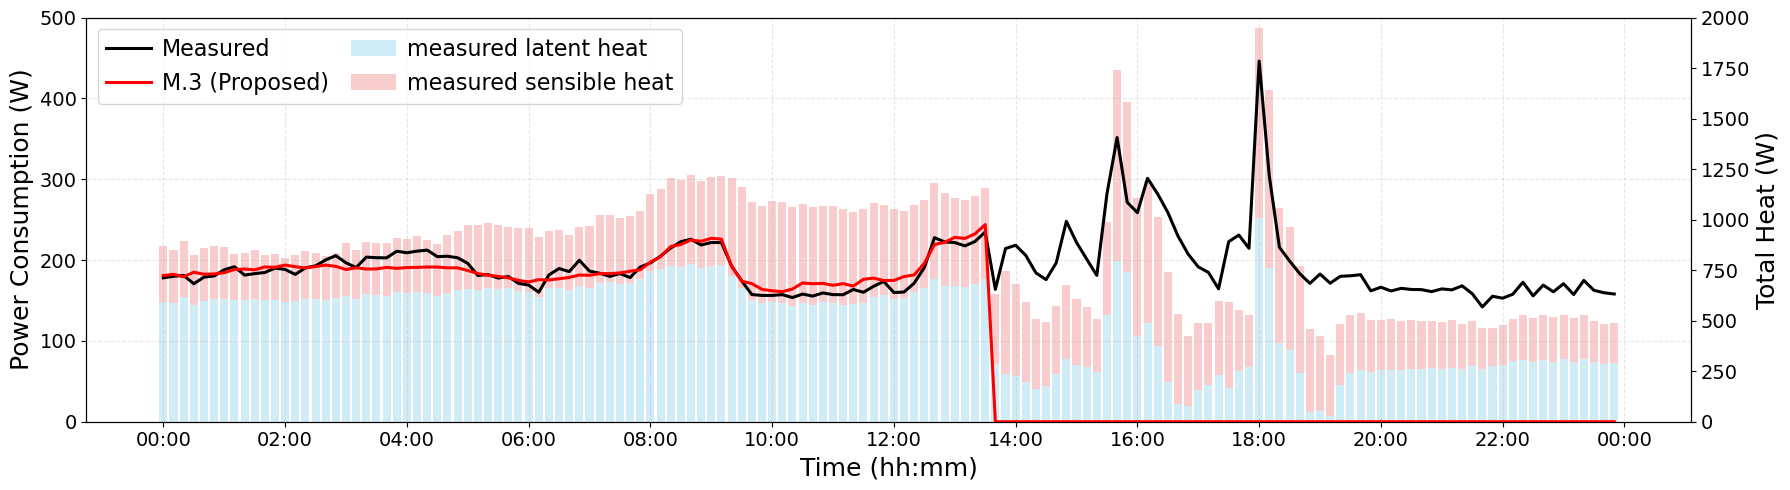

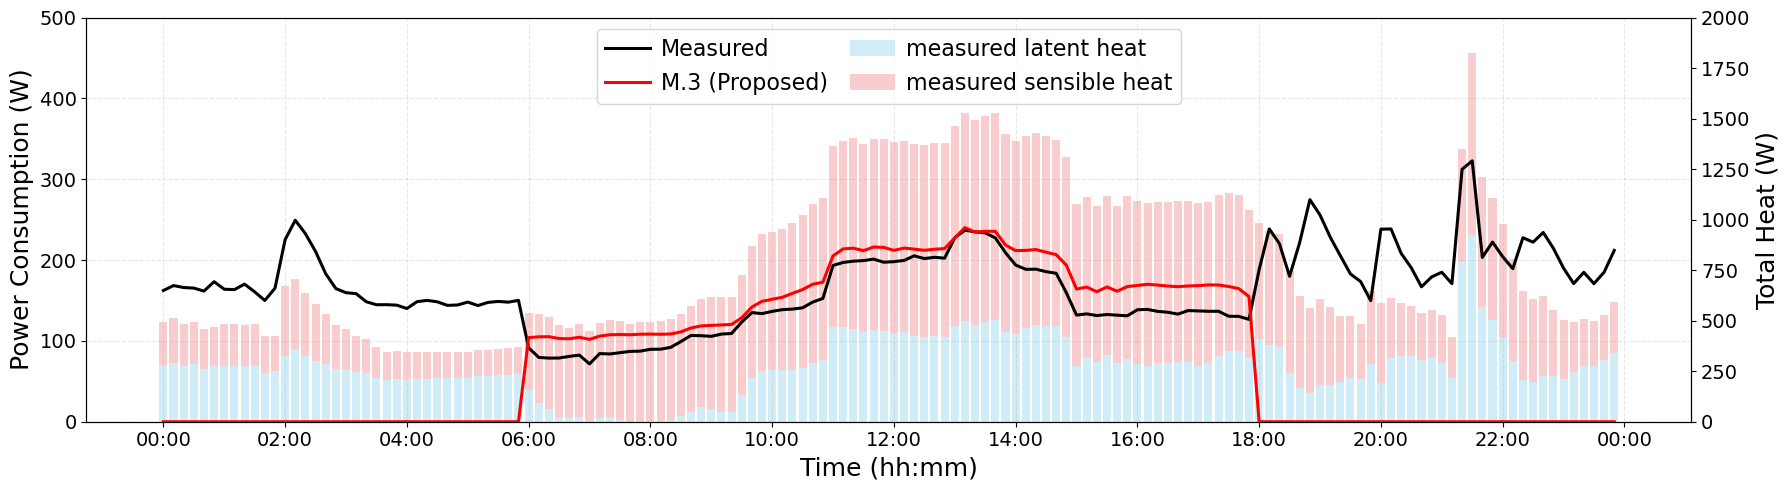

In [ ]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import CoolProp.CoolProp as HAP
import sympy as sp
from scipy.optimize import minimize_scalar
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from scipy.optimize import differential_evolution
from scipy import interpolate
from sklearn.metrics import mean_squared_error

import reheat_dehumidification as rm
# import good_cooling_model_pack as cm
import cooling_dehumidification as cm

def plot_onedayfitting(df_test, P_lst,legend_loc):
    Q_sensible_array = np.array(df_test['Q_sensible'].values, dtype = float)
    Q_latent_array = np.array(df_test['Q_latent'].values, dtype = float)
    P_measured = df_test['Totalenergy'].copy()

    fig, ax1 = plt.subplots(figsize=(18, 5))
    ax2 = ax1.twinx()
    width = 0.0055
    ax2.bar(df_test['Time'], Q_latent_array, width=width, 
            label='measured latent heat', color='skyblue', alpha=0.39)
    ax2.bar(df_test['Time'], Q_sensible_array, width=width, 
            bottom=Q_latent_array, label='measured sensible heat', color='lightcoral', alpha=0.39)

    ax2.set_ylabel('Total Heat (W)', fontsize=18)
    # ax2.legend(loc='lower right', fontsize=16)
    ax2.tick_params(axis='y', which='major', labelsize=14)
    ax2.set_ylim(0,2000)

    line_zorder = 10 
    ax1.plot(df_test['Time'], P_measured, label='Measured', 
            color='black', linewidth=2.2, zorder=line_zorder) # 稍微加粗Measured
    ax1.plot(df_test['Time'], P_lst, label='M.3 (Proposed)', 
            color='red', linewidth=2.2, zorder=line_zorder)
    ax1.set_xlabel('Time (hh:mm)', fontsize=18)
    ax1.set_ylabel('Power Consumption (W)', fontsize=18)
    ax1.legend(loc='lower left', fontsize=16)
    # --- 3. 核心步骤：调整图层顺序和透明度 ---
    # 将 ax1 (线条) 的层级放到 ax2 (柱子) 之上
    ax1.set_zorder(ax2.get_zorder() + 1)
    # **非常重要**：必须将 ax1 的背景设置为透明，否则 ax2 会被完全遮挡
    ax1.patch.set_visible(False) 
    ax1.set_ylim(0,500)
    # --- 4. 格式化时间轴 ---
    # 注意：所有的格式化必须在 ax1 上进行，因为它现在是顶层
    ax1.xaxis.set_major_locator(mdates.HourLocator(interval=2))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    # plt.title('Measured vs Calculated Energy with Q Components', fontsize=16)
    ax1.grid(True, linestyle='--', alpha=0.3, zorder=0) 
    ax1.tick_params(axis='both', which='major', labelsize=14)


    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    # 2. 合并它们
    # 这样合并后，第一列是 Line (Measured/Calculated)，第二列是 Bar (Latent/Sensible)
    all_handles = handles1 + handles2
    all_labels = labels1 + labels2
    # 3. 统一绘制一个 2x2 的图例
    # loc='upper center' 定位在上方中间
    # ncol=2 实现你想要的 2+2 布局
    ax1.legend(all_handles, all_labels, 
               loc=legend_loc, 
               ncol=2, 
               fontsize=16,
               columnspacing=1.0, # 调整左右两列之间的间距
               handletextpad=0.5, # 调整图标与文字之间的间距
               frameon=True)
    # --- 调整整体边距以容纳两行图例 ---
    plt.subplots_adjust(top=0.8) # 这里的 0.8 根据实际效果微调，数值越小上方留白越多
    plt.tight_layout()
    plt.show()

test_data_XYplot = "0614_0810_data_processed_0_7.csv"
df_test1 = pd.read_csv(test_data_XYplot)
df_test1['Time'] = pd.to_datetime(df_test1['Time'])

##################################
# 0615 fitting效果验证
##################################
start_time = "2025-06-15 00:00:00"
end_time = "2025-06-15 23:50:00"
mask = (df_test1['Time'] >= start_time) & (df_test1['Time'] <= end_time)
df_test_reheat_ftting = df_test1.loc[mask].reset_index(drop=True)

P_totals_0615 = []
Q_latents_0615 = []

for e in range(len(df_test_reheat_ftting)):
    print("--------------------------------------------------------------")
    print("real energy",df_test_reheat_ftting["Totalenergy"][e],e)
    # if df_test["Totalenergy"][e] < 10:
    #     P, T_evp_apply, T_cnd_apply, Q_latent_cal, SHF = 0,0,0,0,0
    time_thes = pd.to_datetime("2025-06-15 13:30:00")
    if df_test_reheat_ftting['Time'][e] <= time_thes:
        P, T_evp_apply, T_cnd_apply, Q_latent_cal, SHF = ac_reheat.output(300, df_test_reheat_ftting["Xxiru"][e], df_test_reheat_ftting["Txiru"][e], df_test_reheat_ftting["Tout"][e], (df_test_reheat_ftting["Q_sensible"][e] + df_test_reheat_ftting["Q_latent"][e]), 10)
    else:
        P, Lsensible_apply, Q_latent_cal, T_evp_apply, T_cnd_apply = 0,0,0,0,0 # 冷房大风量：3:00-6:00, 12:00-15:00
        
    print("Calculated energy:", P)
    P_totals_0615.append(P)
    Q_latents_0615.append(Q_latent_cal)


##################################
# 0701 fitting效果验证
##################################
start_time = "2025-07-01 00:00:00"
end_time = "2025-07-01 23:50:00"
mask = (df_test1['Time'] >= start_time) & (df_test1['Time'] <= end_time)
df_test_cooling_ftting = df_test1.loc[mask].reset_index(drop=True)

P_totals_0701 = []
Q_latents_0701 = []

for e in range(len(df_test_cooling_ftting)):
    print("--------------------------------------------------------------")
    print("real energy",df_test_cooling_ftting["Totalenergy"][e],e)
    # if df_test["Totalenergy"][e] < 10:
    #     P, T_evp_apply, T_cnd_apply, Q_latent_cal, SHF = 0,0,0,0,0
    time_tres1 = pd.to_datetime("2025-07-01 06:00:00")
    time_tres2 = pd.to_datetime("2025-07-01 17:50:00")
    if df_test_cooling_ftting['Time'][e] >= time_tres1 and df_test_cooling_ftting['Time'][e] <= time_tres2:
        P, Lsensible_apply, Q_latent_cal, T_evp_apply, T_cnd_apply = ac_cool.ac_output(df_test_cooling_ftting["Q_total"][e],df_test_cooling_ftting["Txiru"][e],df_test_cooling_ftting["Xxiru"][e],df_test_cooling_ftting["Tout"][e], 696)
    else:
        P, Lsensible_apply, Q_latent_cal, T_evp_apply, T_cnd_apply = 0,0,0,0,0 # 冷房大风量：3:00-6:00, 12:00-15:00
        
    print("Calculated energy:", P)
    P_totals_0701.append(P)
    Q_latents_0701.append(Q_latent_cal)

plot_onedayfitting(df_test_reheat_ftting, P_totals_0615, "upper left")
plot_onedayfitting(df_test_cooling_ftting, P_totals_0701, "upper center")